In this notebook, we try to solve the one norm problem with cost function 

\begin{equation}
    J(u) = \|Au - b\|_2^2 + \alpha \|u\|_1
\end{equation}

by rewriting it into a least squares problem and using normal equations to solve the leastsquares problem. In each iteration, the least squares problem is

\begin{equation*}
    u_{k+1} = \arg\min_u \left\| \begin{bmatrix}
        A\\
        \sqrt{\alpha} W^{1/2}_k
    \end{bmatrix}u - \begin{bmatrix}
        b\\
        0
    \end{bmatrix}\right\|_2^2
\end{equation*}

with $W_k = \text{diag}\{u^{-1}_k\}$

The normal equations are given as 

\begin{equation}
    (A^TA + \alpha W_k)^{-1}A^Tb = u
\end{equation}

In [8]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, L2NormSquared

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, CompositionOperator

import scipy as sp

In [9]:
# setting pixels and angles
n_pixels = 256
n_angles = 50

## Setting up phantom system and defaults

In [10]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [1]:
def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom

## Solving by self implementation of CG

In [2]:
def apply_operator(x, W, alpha):

    """
    Applies the operator 
    
    A^TA + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * W)x
    """
    
    # z2 = (A^TA)x
    z1 = A.direct(x)
    z2 = A.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

In [6]:
def CG(initial, iteration, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * W_k)u = A^Ty

    using CG

    Input:
        initial:    initial guess for u (ImageData)
        iteration:  maximum number of iterations used (integer)
        b:          lhs, that is A^Tb (ImageData)
        alpha:      regularisation parameter (float)
        W_k:        weights (ImageData)
    """

    u0 = initial.copy()
    r0 = b - apply_operator(u0, Wk, alpha)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(iteration):
        zk = apply_operator(pk, Wk, alpha)

        # NOTE: might need to find something better than adding 1e-6
        alpha_k = delta_new/(pk.dot(zk.conjugate()))

        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

In [3]:
def CG_check(initial, max_iter, A, ATb, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    (apply_operator)u = A^Tb

    using CG

    """

    u0 = initial.copy()
    r0 = ATb - apply_operator(x=u0, W=Wk, A=A, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    cg_tol *= 2
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator(x=pk, W=Wk, A=A, alpha=alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uk = uk_plus_one
            inner_iter_count = k + 1
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr, inner_iter_count

In [ ]:
def onenorm_normal(max_outer, max_inner, initial, A, b, alpha, er):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha*W_k)u = A^Tb

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        max_outer:  Number of outer iterations (scalar)
        max_inner:  Number of CG interations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        b:          The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    lhs = A.adjoint(b)
    get_ig = A.domain_geometry()

    # setting initials
    uk = initial.copy()
    for k in range(max_outer):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = uk_grad_np[large_values] ** (-1)

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing CG
        cg_output = CG_check(uk, max_inner, A, lhs, alpha, uk_reweighted, 1e-2, apply_operator)

        uk = cg_output

    return uk

## Results

In [9]:
sino_noise = add_poss_noise(20000, n_angles, n_pixels)
A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

x0 = ig.allocate(0)
alpha = 0.0008
lets_hope = onenorm_normal(10, 15, x0, A, sino_noise, alpha, 0.0001)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


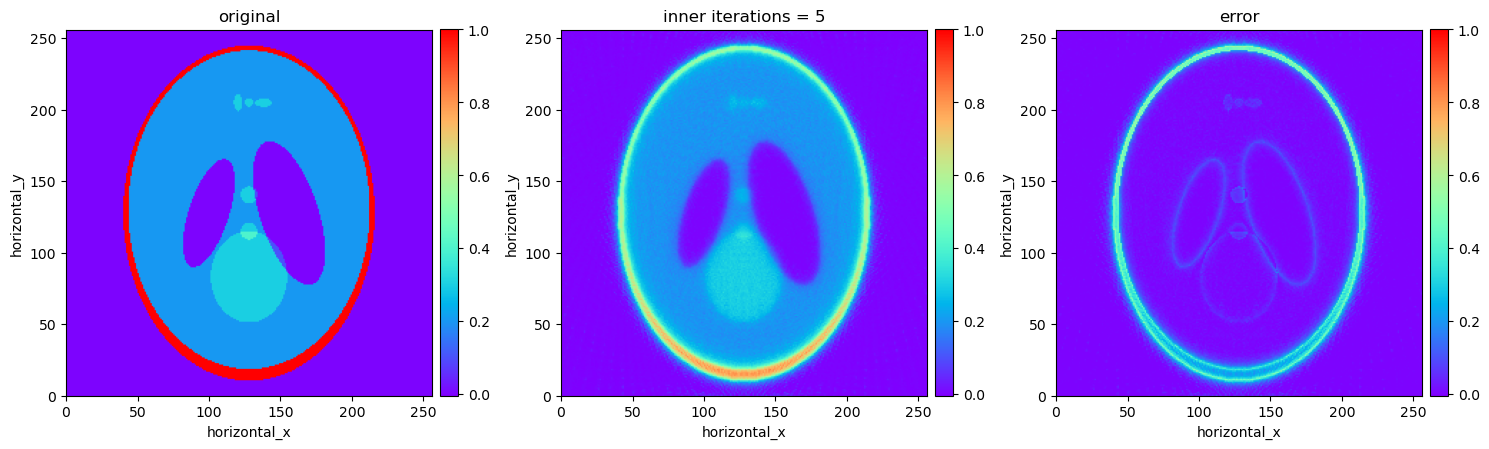

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


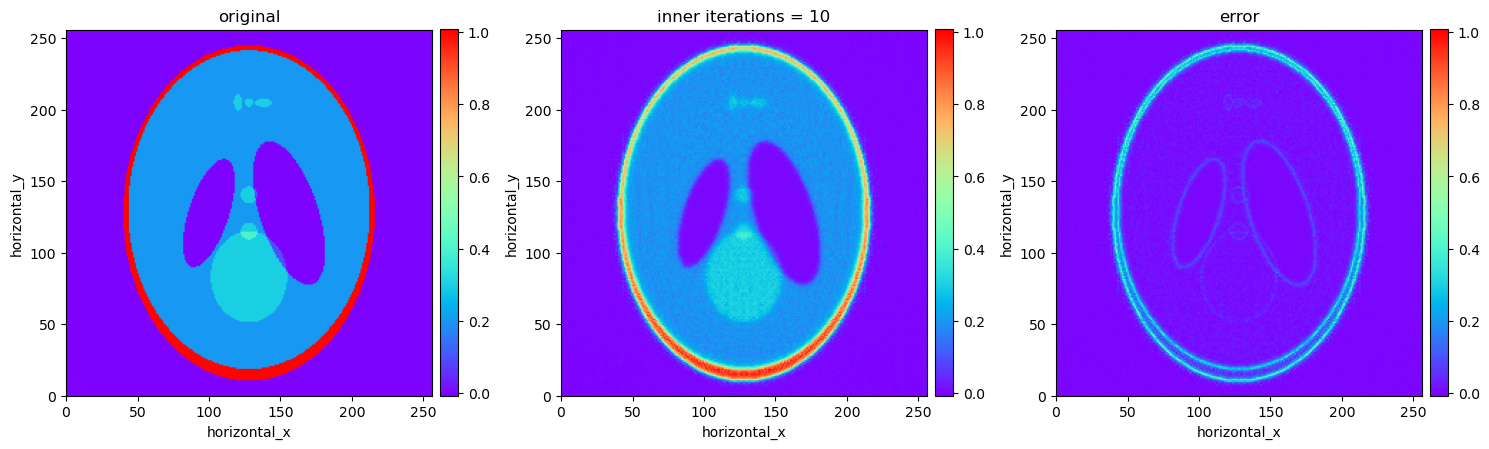

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


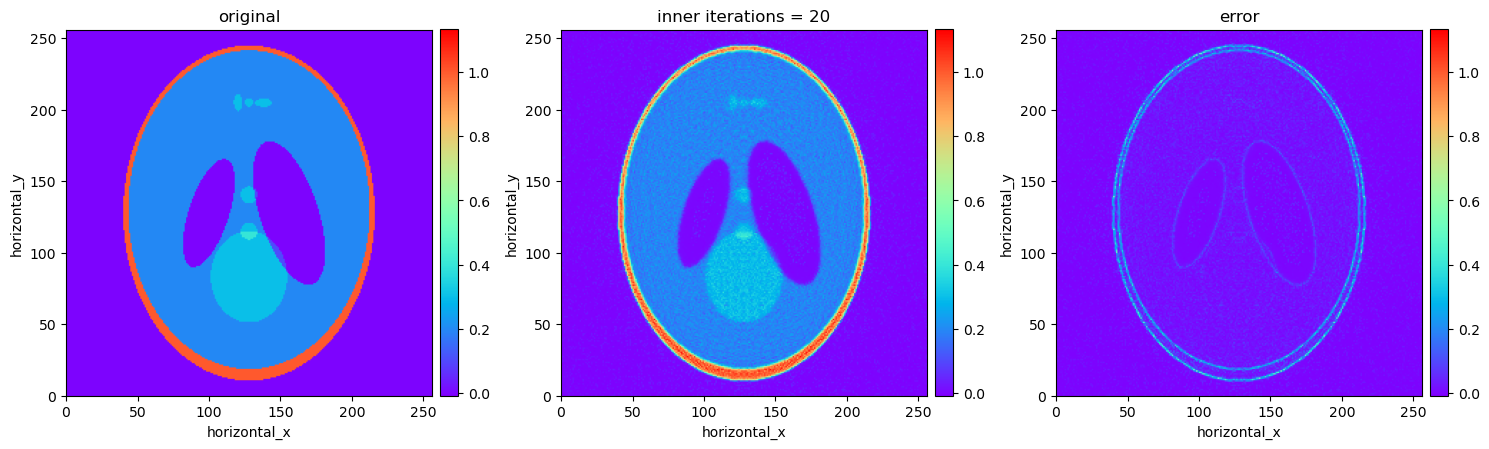

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


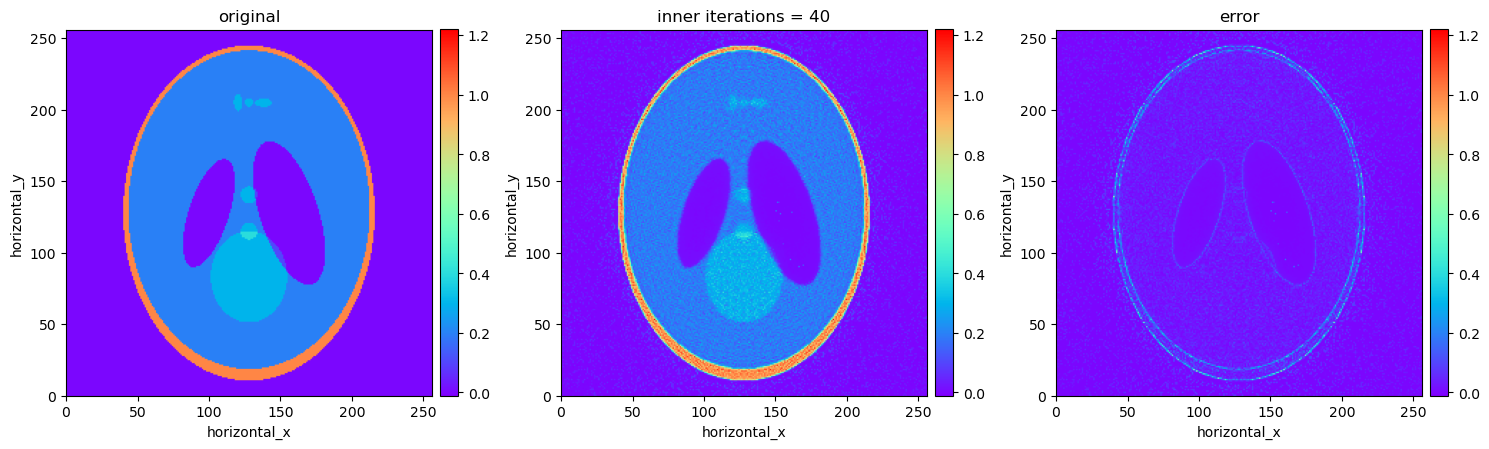

In [25]:
for inner in [5, 10, 20, 40]:
    sol = onenorm_normal(10, inner, x0, A, sino, 0.0008, 0.0001)
    error = (phantom - sol).abs()
    show2D([phantom, sol, error], ['original', f'inner iterations = {inner}', 'error'], cmap=cmap, num_cols=3, fix_range=True)

## Final code

In [12]:
def apply_operator_onenorm(x, W, A, alpha):

    """
    Applies the operator 
    
    A^TA + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * W)x
    """
    
    # z2 = (A^TA)x
    z1 = A.direct(x)
    z2 = A.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

def CG(initial, max_iter, A, ATb, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    apply_operator(u) = A^Tb (*)

    using Conjugate Gradient (CG)

    INPUT:
        initial:    Inital guess for u (ImageData)
        max_iter:   Maximum number of cg iterations (float)
        A:          ProjectionOperator necessary for 'apply_operator' function
        ATb:        A^Tb (ImageData)
        alpha:      Regularisation parameter (float)
        Wk:         Weights in the kth iteration, necessary for `apply_operator' function (ImageData)
        cg_tol:     Tolerance on CG (float)
        apply_operator: Function that applies matrix from normal equation
    
    OUTPUT:
        uk:     Minimiser of (*) (ImageData)
        conv_arr:     Array with residuals from each iteration (numpy array)
        inner_iter_count:   Number of inner iterations used (float)
    """

    u0 = initial.copy()
    r0 = ATb - apply_operator(x=u0, W=Wk, A=A, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    cg_tol *= 2
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator(x=pk, W=Wk, A=A, alpha=alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uk = uk_plus_one
            inner_iter_count = k + 1
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr, inner_iter_count


def onenorm_normal(initial, inner_iter, outer_iter, A, sino, alpha, er, cg_tol, exact):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha*W_k)u = A^Tb

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        initial:    Initial guess for u (ImageData)
        inner_iter: Number of CG iterations (scalar)
        outer_iter: Number of outer iterations (scalar)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    lhs = A.adjoint(sino)

    # setting initials
    uk = initial.copy()
    get_ig = A.domain_geometry()

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    inner_itercount_arr = []

    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2*(uk_grad_np[large_values] ** (-1))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing CG
        cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, apply_operator_onenorm)
        inner_itercount_arr.append(inner_iter_count)

        uk = cg_output
        Auk_min_sino = A.direct(uk) - sino

        if exact == None:
            err_temp = norm(Auk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Auk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 5 iterations
outer iteration: 3
cg converged in 7 iterations
outer iteration: 4
cg converged in 9 iterations
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


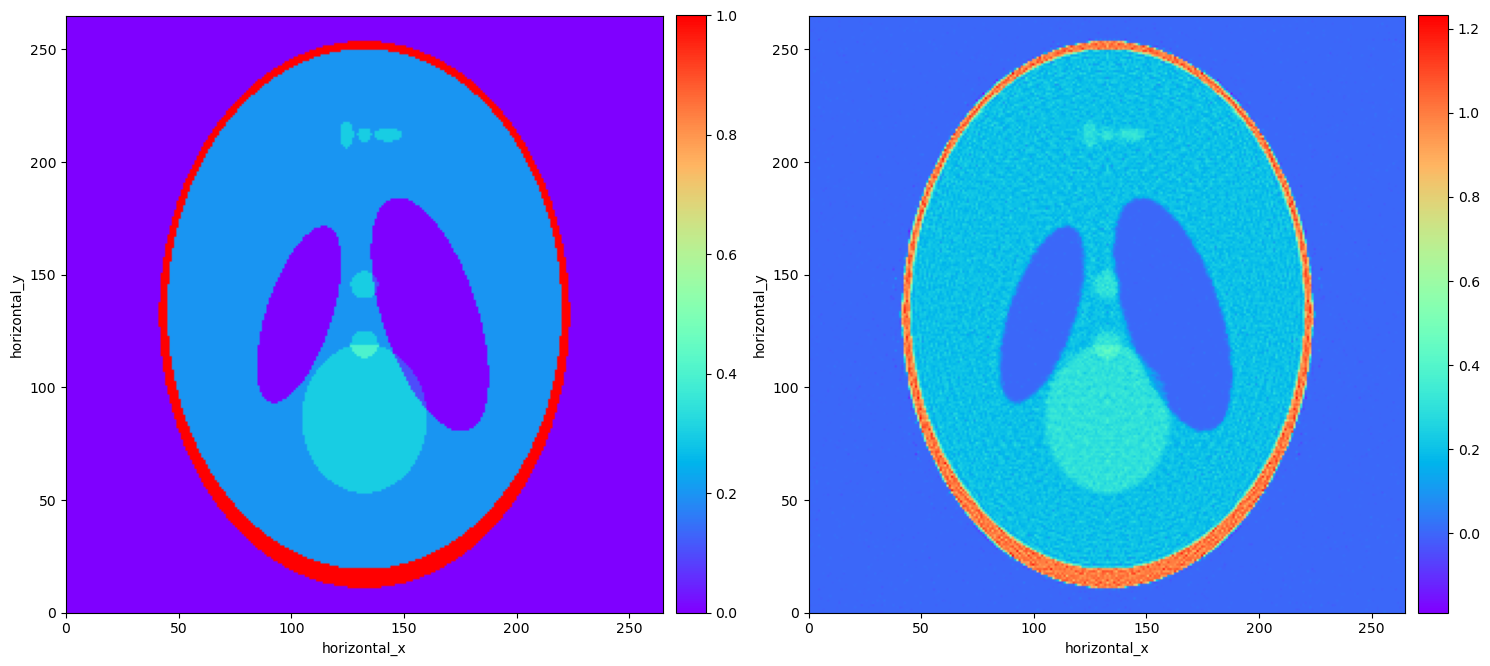

In [11]:
n_pixels = 265
n_angles = 50
sino_noise = add_poss_noise(20000, n_angles, n_pixels)
A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

sol, sol_err, cg_convergence, inner_iterationscounter = onenorm_normal(initial = ig.allocate(0), 
                                                                       inner_iter = 100, 
                                                                       outer_iter = 10, 
                                                                       A = A, 
                                                                       sino = sino, 
                                                                       alpha = 1e-6, 
                                                                       er = None, 
                                                                       cg_tol = 1e-2, 
                                                                       exact = phantom)

show2D([phantom, sol], cmap = 'rainbow')

In [36]:
import time
sino_noise = add_poss_noise(20000, n_angles, n_pixels)
A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

tstart = time.time()
sol, sol_err, conv_array, inner_iterationscounter = onenorm_normal(initial= ig.allocate(0), 
                                                                    inner_iter = 10, 
                                                                    outer_iter = 10, 
                                                                    A = A, 
                                                                    sino = sino_noise, 
                                                                    alpha = 0.0008, 
                                                                    er = None, 
                                                                    cg_tol = 1e-2, 
                                                                    exact = phantom)
tend = time.time()

print("time for computation:", tend-tstart)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 3 iterations
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
time for computation: 6.284178018569946


<>:12: SyntaxWarning: invalid escape sequence '\|'
<>:12: SyntaxWarning: invalid escape sequence '\|'
C:\Users\femke\AppData\Local\Temp\ipykernel_32564\3622157133.py:12: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|u_{exact} - u\|_2^2$')


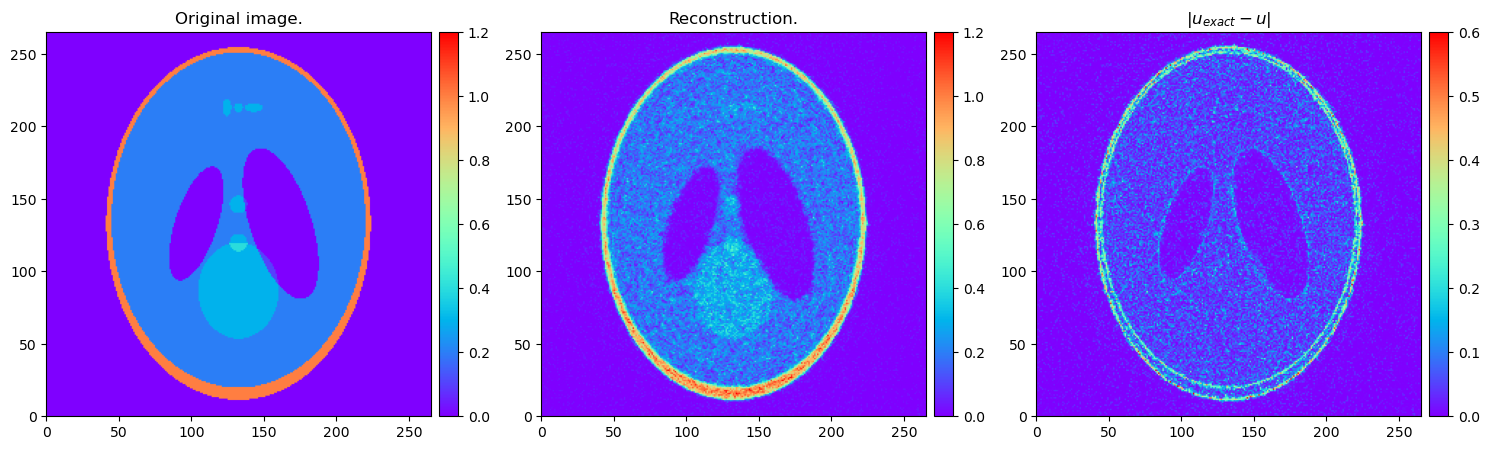

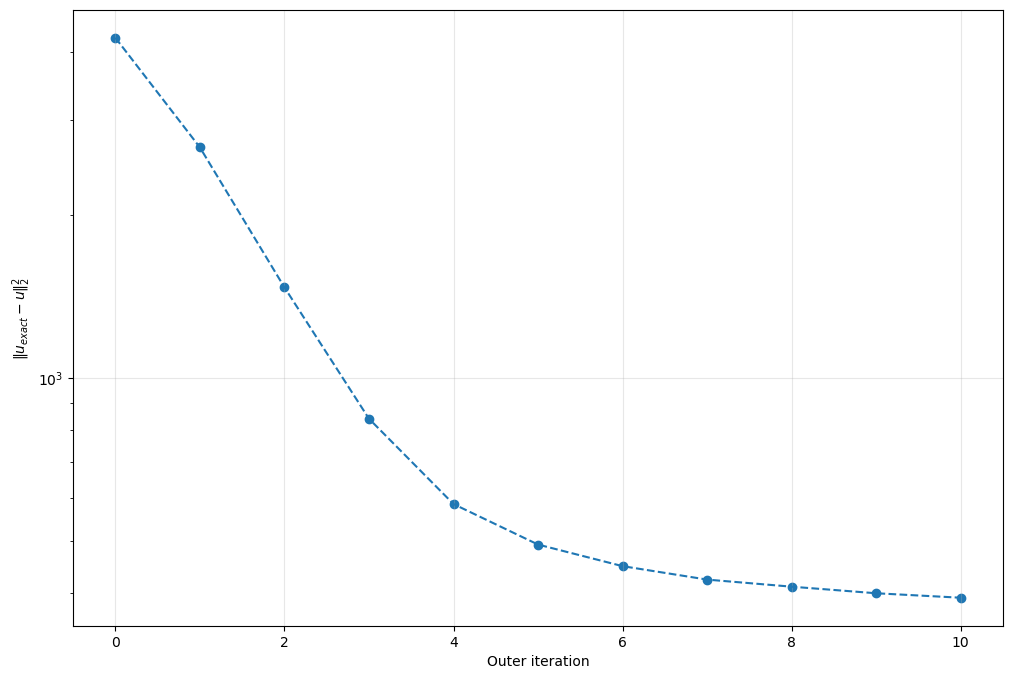

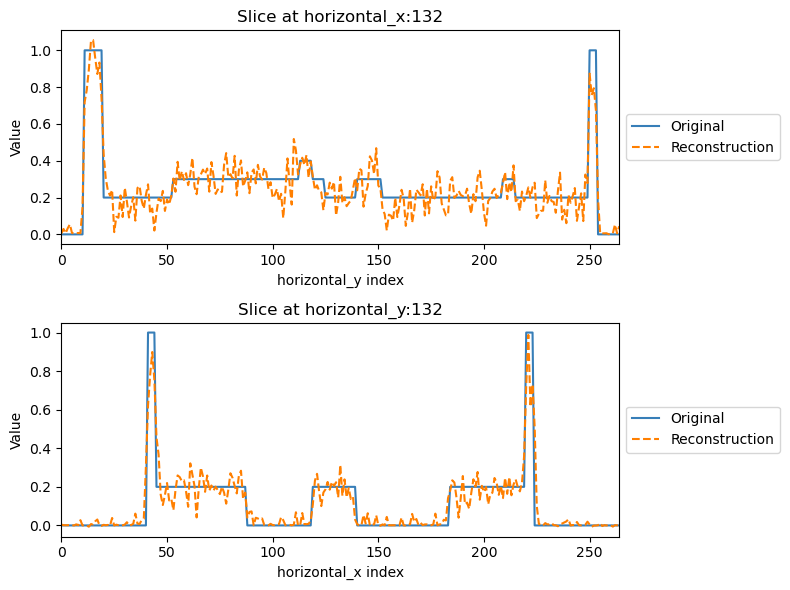

In [38]:
error = (phantom - sol).abs()
show2D([phantom, sol.abs(), error], ['Original image.', 'Reconstruction.', '$|u_{exact} - u|$'], 
       cmap=cmap, 
       num_cols=3, 
       fix_range=[(0,1.2), (0,1.2), (0,0.6)], 
       axis_labels=('',''))

x = np.linspace(0,len(sol_err) - 1, len(sol_err))

plt.figure(figsize=(12,8))
plt.semilogy(x, sol_err, linestyle='--')
plt.ylabel('$\|u_{exact} - u\|_2^2$')
plt.xlabel('Outer iteration')
plt.scatter(x,sol_err)
plt.grid(alpha=0.3)

show1D([phantom, sol], dataset_labels=['Original', 'Reconstruction'])